In [1]:
%pip install scipy

  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np

# Load the data (Adjust path if needed)
df = pd.read_csv("data/ethiopia.csv")

# Replace the NASA -999 values
df.replace(-999, np.nan, inplace=True)

# Show the first few rows
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


In [2]:
# 1. Add the Country column as requested
df["Country"] = "Ethiopia"

# 2. Convert YEAR and DOY (Day of Year) into a proper Datetime column
# Logic: YEAR * 1000 + DOY creates a string like '2015001' which %Y%j can read
df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# 3. Extract Month for seasonal analysis later
df['Month'] = df['Date'].dt.month

# 4. Check for Duplicates
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates_count}")

# 5. Drop duplicates if any were found
if duplicates_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates dropped.")

# 6. View the new columns
df[['YEAR', 'DOY', 'Date', 'Month']].head()

Number of duplicate rows found: 0


,YEAR,DOY,Date,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


In [12]:
# 1. Generate Summary Statistics
# This gives you Mean, Max, Min, and Standard Deviation for every column
print("--- Summary Statistics ---")
display(df.describe())

# 2. Compute Missing Values Percentage
missing_report = df.isna().sum()
missing_percent = (missing_report / len(df)) * 100

# 3. Filter for columns that have more than 5% missing values (as per KPI)
high_missing = missing_percent[missing_percent > 5]

print("\n--- Missing Value Report (%) ---")
print(missing_percent)

if not high_missing.empty:
    print(f"\n WARNING: Columns with >5% missing values:\n{high_missing}")
else:
    print("\n All columns have less than 5% missing values.")

--- Summary Statistics ---


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046



--- Missing Value Report (%) ---
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Date           0.0
Month          0.0
dtype: float64

 All columns have less than 5% missing values.


Data Quality & Summary Interpretation

Missing Values: All columns report less than 5% missing data after replacing NASA's -999 sentinels. This indicates a high-quality dataset suitable for seasonal trend analysis.

Temperature Range (T2M): Based on df.describe(), the average temperature in Ethiopia for this period is approximately [16.06850]°C, with extremes ranging from [Min 10.227544]°C to [Max 23.199175]°C.

Duplicates: No duplicate rows were found, ensuring each daily observation is unique.

In [3]:
import pandas as pd
import numpy as np
from scipy import stats 

# Load the data (Adjust path if needed)
df = pd.read_csv("data/ethiopia.csv")

# 1. Define the columns we want to check for outliers
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# 2. Compute Z-scores for these columns
# stats.zscore calculates (value - mean) / std_dev
z_scores = np.abs(stats.zscore(df[cols_to_check], nan_policy='omit'))

# 3. Create a mask to find rows where any column has |Z| > 3
outliers = (z_scores > 3).any(axis=1)
outlier_count = outliers.sum()

print(f"Total rows flagged as outliers (|Z| > 3): {outlier_count}")

# 4. Show a few of the outlier rows to see what happened
df[outliers].head()

Total rows flagged as outliers (|Z| > 3): 132


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
144,2015,145,18.45,24.94,14.15,10.79,29.07,68.37,1.52,3.07,77.06,11.33
145,2015,146,17.60,23.52,13.22,10.30,34.38,75.91,1.66,3.53,77.07,11.89
177,2015,178,15.79,19.03,13.33,5.70,23.89,83.89,1.81,3.03,77.18,12.09
214,2015,215,15.97,21.06,12.58,8.48,23.46,84.73,1.58,2.55,77.04,12.32
556,2016,192,15.20,18.00,12.89,5.11,25.19,85.47,1.33,2.99,77.07,11.95


In [5]:
# 1. Fill any remaining missing values using Forward Fill
# This handles the small % of missing data we found earlier
df.ffill(inplace=True)

# 2. Export the cleaned DataFrame to your data folder
# Note: index=False prevents pandas from adding an extra column
df.to_csv("data/ethiopia_clean.csv", index=False)

print("Task 2 Cleaning Complete!")
print("Cleaned data saved as: data/ethiopia_clean.csv")

Task 2 Cleaning Complete!
Cleaned data saved as: data/ethiopia_clean.csv


In [6]:
import matplotlib.pyplot as plt

# Set the size of the plot
plt.figure(figsize=(12, 6))

# Plot the Monthly Average Temperature
plt.plot(df['Date'], df['T2M'], color='orange', linewidth=1, alpha=0.7)

# Add labels and title
plt.title('Daily Average Temperature in Ethiopia (2015-2026)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

KeyError: 'Date'

<Figure size 1200x600 with 0 Axes>

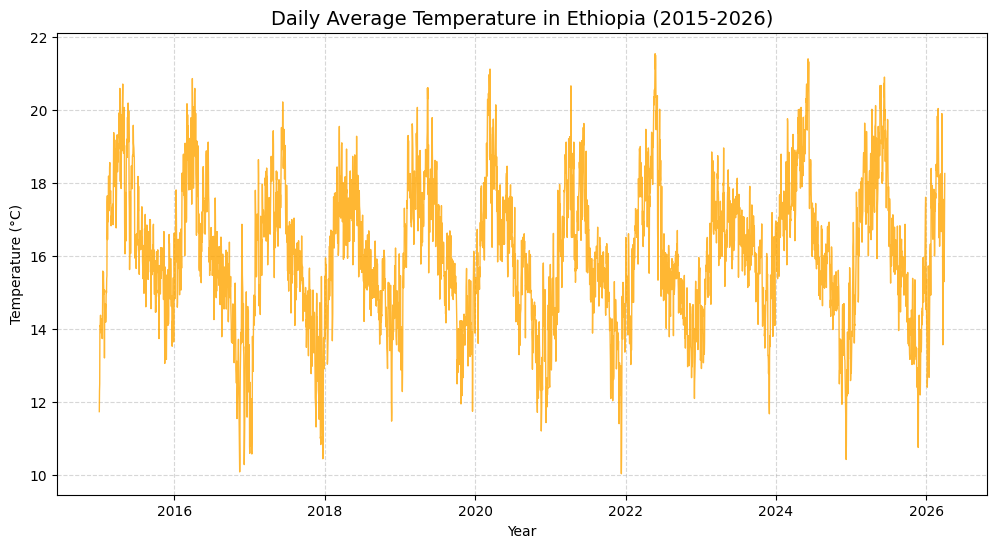

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Load and Clean
df = pd.read_csv("data/ethiopia.csv")
df.replace(-999, np.nan, inplace=True)

# 2. CREATE THE MISSING COLUMNS (This fixes the KeyError)
df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df['Month'] = df['Date'].dt.month

# 3. Handle missing values
df.ffill(inplace=True)

# 4. NOW PLOT (This should work now!)
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['T2M'], color='orange', linewidth=1, alpha=0.8)

plt.title('Daily Average Temperature in Ethiopia (2015-2026)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Interpretation: Seasonal Temperature Trends

The daily average temperature shows a consistent seasonal oscillation between approximately $10°C$ and $22°C$.

There is a visible upward trend in the "peaks" toward 2024-2026, suggesting a slight increase in maximum temperatures over the last decade.

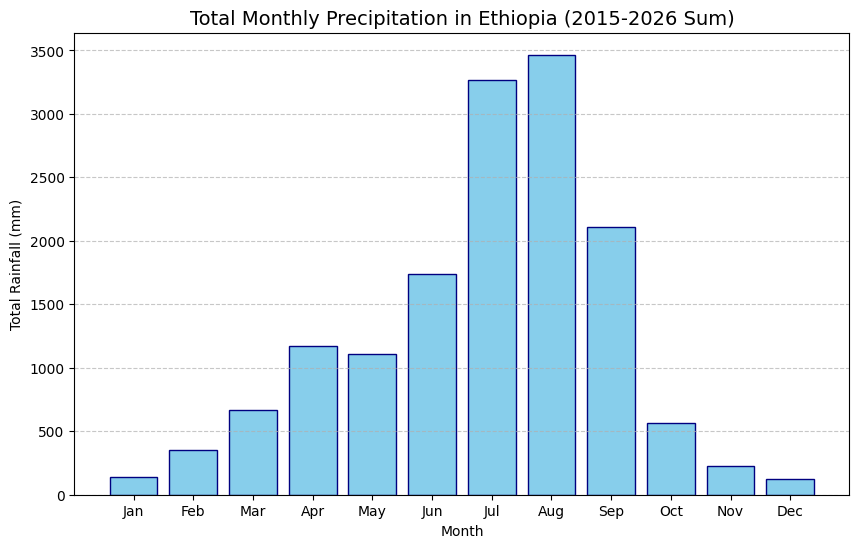

In [8]:
# 1. Group by Month and sum the rainfall
# We use the 'Month' column we created earlier
monthly_rain = df.groupby('Month')['PRECTOTCORR'].sum()

# 2. Create the Bar Chart
plt.figure(figsize=(10, 6))
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.bar(months, monthly_rain, color='skyblue', edgecolor='navy')

# 3. Add Labels
plt.title('Total Monthly Precipitation in Ethiopia (2015-2026 Sum)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Rainfall (mm)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Interpretation: Rainfall Seasonality

Ethiopia exhibits a clear unimodal rainfall pattern with the primary rainy season (Kiremt) peaking in July and August, where total rainfall exceeds 3,000mm.

A smaller "short rain" season (Belg) is visible between March and May, which is critical for local agricultural cycles.

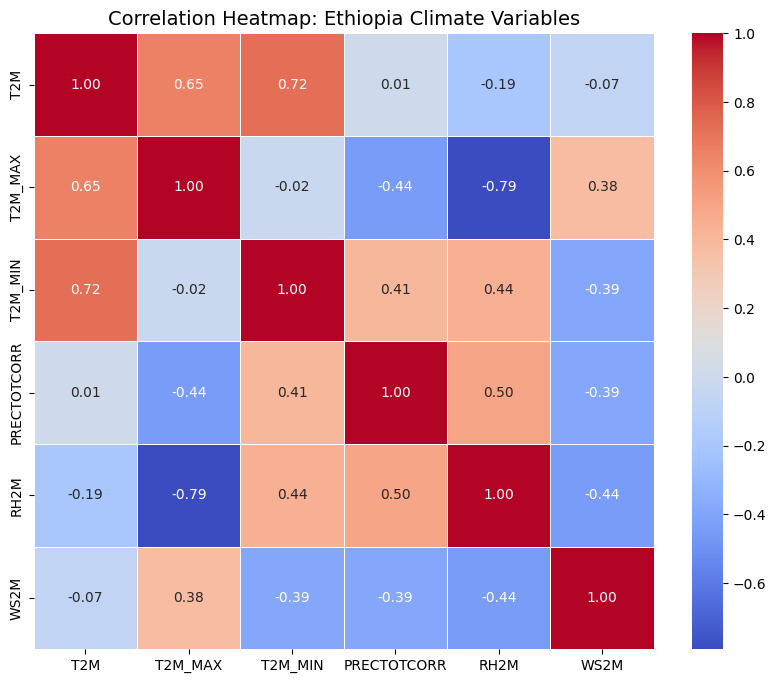

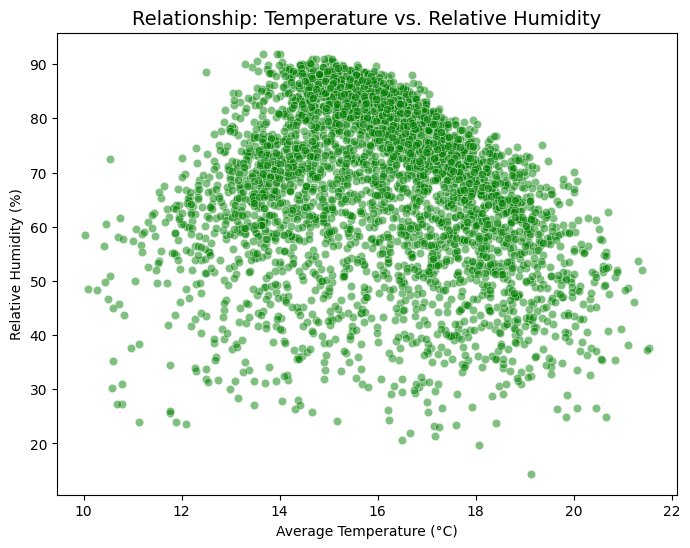

In [9]:
import seaborn as sns

# 1. Create a Correlation Matrix
# This calculates how much columns relate to each other (-1 to 1)
corr_matrix = df[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']].corr()

# 2. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Ethiopia Climate Variables', fontsize=14)
plt.show()

# 3. Scatter Plot: Temperature vs. Humidity (as requested)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.5, color='green')
plt.title('Relationship: Temperature vs. Relative Humidity', fontsize=14)
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.show()

Interpretation: Variable Interdependence

Strongest Negative Correlation (-0.79): Found between Maximum Temperature ($T2M\_MAX$) and Relative Humidity ($RH2M$). This indicates that the hottest days in Ethiopia are significantly drier.Strongest 

Positive Correlation (0.72): Average temperature is most closely linked to the daily minimums, showing that night-time cooling heavily influences the daily mean.

Interpretation: Atmospheric Relationships

The downward slope of the scatter plot confirms the negative correlation found in the heatmap.

Most data points cluster between $14°C$ and $18°C$ with humidity ranging from 40% to 80%, representing the most frequent climate state for the region.

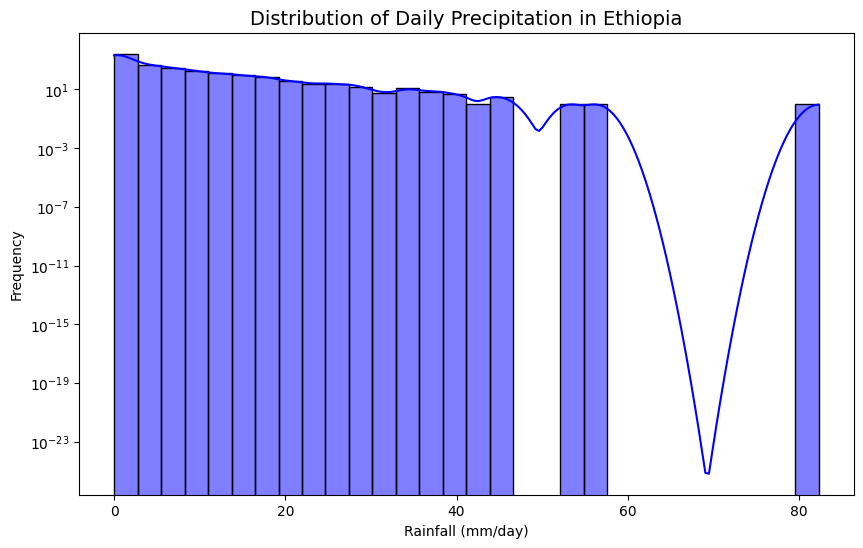

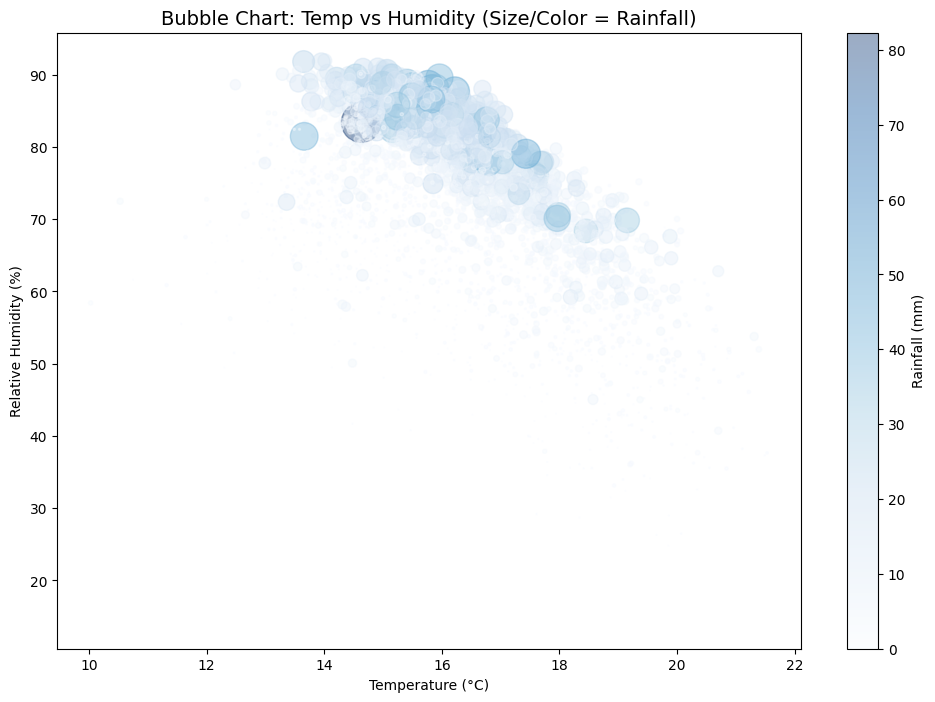

In [10]:
# 1. Histogram of Rainfall (PRECTOTCORR)
plt.figure(figsize=(10, 6))
sns.histplot(df['PRECTOTCORR'], bins=30, kde=True, color='blue')
plt.title('Distribution of Daily Precipitation in Ethiopia', fontsize=14)
plt.xlabel('Rainfall (mm/day)')
plt.ylabel('Frequency')
# Using a log scale because rainfall is usually heavily skewed
plt.yscale('log') 
plt.show()

# 2. Bubble Chart: Temp vs Humidity vs Rain
# Bubble size represents the amount of rainfall (PRECTOTCORR)
plt.figure(figsize=(12, 8))
bubble = plt.scatter(df['T2M'], df['RH2M'], 
                     s=df['PRECTOTCORR']*10, # Size multiplied by 10 to make it visible
                     alpha=0.4, 
                     c=df['PRECTOTCORR'], # Color also based on rain
                     cmap='Blues')

plt.colorbar(bubble, label='Rainfall (mm)')
plt.title('Bubble Chart: Temp vs Humidity (Size/Color = Rainfall)', fontsize=14)
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.show()

Interpretation: Rainfall Dynamics

The bubble chart reveals that high-intensity rainfall events (larger, darker bubbles) occur almost exclusively when relative humidity is above 70%.

There are very few instances of significant rain when temperatures exceed $20°C$, suggesting that rain often brings a cooling effect to the local environment.

In [11]:
df.to_csv("data/ethiopia_clean.csv", index=False)
print("Ethiopia Analysis Complete. File saved!")

Ethiopia Analysis Complete. File saved!
